In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_ROOT = Path.cwd().parent

BASELINE_DIR = (
    PROJECT_ROOT
    / "metadata"
    / "baseline"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "baseline"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [2]:
inner_runs = pd.read_csv(
    BASELINE_DIR
    / "chbmit_inner_training_runs.csv"
)

inner_metrics = pd.read_csv(
    BASELINE_DIR
    / "chbmit_inner_metrics.csv"
)

thresholds = pd.read_csv(
    BASELINE_DIR
    / "chbmit_inner_thresholds.csv"
)

selected = pd.read_csv(
    BASELINE_DIR
    / "chbmit_selected_baseline_config.csv"
)

outer_metrics = pd.read_csv(
    BASELINE_DIR
    / "chbmit_outer_metrics.csv"
)

predictions = pd.read_csv(
    BASELINE_DIR
    / "chbmit_outer_predictions.csv"
)

# Inner Performance

In [3]:
inner_metrics[
    [
        "average_precision",
        "roc_auc",
        "sensitivity",
        "specificity",
        "precision",
        "f1",
        "balanced_accuracy",
        "matthews_corrcoef",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
average_precision,20.0,0.132781,0.108533,0.018579,0.047099,0.083162,0.207034,0.400406
roc_auc,20.0,0.842548,0.094775,0.617591,0.818804,0.880336,0.900860,0.953768
sensitivity,20.0,0.223297,0.097317,0.073380,0.137643,0.208605,0.301517,0.398079
specificity,20.0,0.995659,0.005397,0.981586,0.996670,0.997527,0.998627,0.999427
precision,20.0,0.262883,0.180095,0.031403,0.106151,0.248729,0.363476,0.623446
f1,20.0,0.218250,0.117965,0.051227,0.116030,0.189980,0.303901,0.468005
balanced_accuracy,20.0,0.609478,0.048768,0.534517,0.565535,0.603244,0.643773,0.698611
matthews_corrcoef,20.0,0.226607,0.119662,0.058598,0.124144,0.199294,0.315290,0.474174


# Threshold Stability

In [4]:
thresholds.groupby(
    "outer_fold"
)["threshold"].agg(
    [
        "mean",
        "std",
        "median",
        "min",
        "max",
    ]
)

,mean,std,median,min,max
outer_fold,,,,,
0,0.722727,0.233135,0.762323,0.405960,0.960303
1,0.565581,0.265291,0.559394,0.306970,0.836566
2,0.782121,0.249217,0.868737,0.420808,0.970202
3,0.597753,0.129910,0.613838,0.445556,0.717778
4,0.660859,0.099360,0.678182,0.524747,0.762323


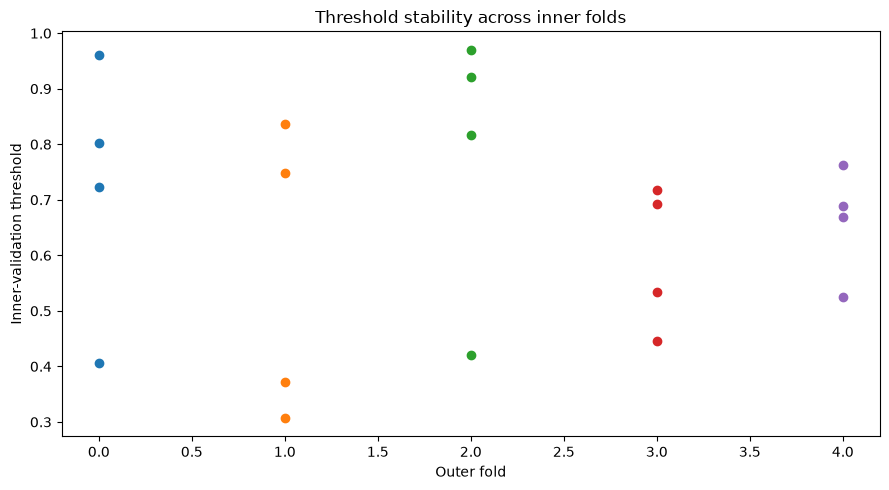

In [5]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

for outer_fold, group in (
    thresholds.groupby(
        "outer_fold"
    )
):
    ax.scatter(
        [outer_fold]
        * len(group),
        group["threshold"],
    )

ax.set_xlabel(
    "Outer fold"
)

ax.set_ylabel(
    "Inner-validation threshold"
)

ax.set_title(
    "Threshold stability across inner folds"
)

fig.tight_layout()

plt.show()

# Best Epoch Stability

In [6]:
inner_runs.groupby(
    "outer_fold"
)["best_epoch"].agg(
    [
        "mean",
        "std",
        "median",
        "min",
        "max",
    ]
)

,mean,std,median,min,max
outer_fold,,,,,
0,7.75,8.261356,4.5,2,20
1,5.25,4.924429,5.0,1,10
2,13.50,8.582929,16.5,1,20
3,4.75,3.500000,4.5,1,9
4,5.50,1.000000,5.0,5,7


# Outer CNN Results

In [7]:
cnn_outer = outer_metrics.loc[
    outer_metrics[
        "model_name"
    ]
    == "simple_cnn_v1"
].copy()

cnn_outer[
    [
        "outer_fold",
        "average_precision",
        "roc_auc",
        "sensitivity",
        "specificity",
        "precision",
        "f1",
        "balanced_accuracy",
        "matthews_corrcoef",
    ]
]

,outer_fold,average_precision,roc_auc,sensitivity,specificity,precision,f1,balanced_accuracy,matthews_corrcoef
1,0,0.062724,0.865748,0.042693,0.999503,0.250000,0.072931,0.521098,0.101944
3,1,0.036046,0.908962,0.309498,0.982479,0.047533,0.082410,0.645988,0.115326
5,2,0.003918,0.540678,0.029950,0.957474,0.002704,0.004960,0.493712,-0.003854
7,3,0.023745,0.887909,0.038634,0.998007,0.049482,0.043391,0.518321,0.041455
9,4,0.018556,0.499815,0.110114,0.961067,0.013865,0.024628,0.535591,0.025705


# Mean ± SD

In [8]:
metric_columns = [
    "average_precision",
    "roc_auc",
    "sensitivity",
    "specificity",
    "precision",
    "f1",
    "balanced_accuracy",
    "matthews_corrcoef",
]

summary = pd.DataFrame(
    {
        "mean": (
            cnn_outer[
                metric_columns
            ].mean()
        ),
        "std": (
            cnn_outer[
                metric_columns
            ].std(
                ddof=1
            )
        ),
        "median": (
            cnn_outer[
                metric_columns
            ].median()
        ),
        "q25": (
            cnn_outer[
                metric_columns
            ].quantile(
                0.25
            )
        ),
        "q75": (
            cnn_outer[
                metric_columns
            ].quantile(
                0.75
            )
        ),
    }
)

summary

,mean,std,median,q25,q75
average_precision,0.028997,0.022095,0.023745,0.018556,0.036046
roc_auc,0.740622,0.202271,0.865748,0.540678,0.887909
sensitivity,0.106178,0.118066,0.042693,0.038634,0.110114
specificity,0.979706,0.019851,0.982479,0.961067,0.998007
precision,0.072717,0.101204,0.047533,0.013865,0.049482
f1,0.045664,0.032397,0.043391,0.024628,0.072931
balanced_accuracy,0.542942,0.059539,0.521098,0.518321,0.535591
matthews_corrcoef,0.056115,0.050848,0.041455,0.025705,0.101944


# AUPRC Plot

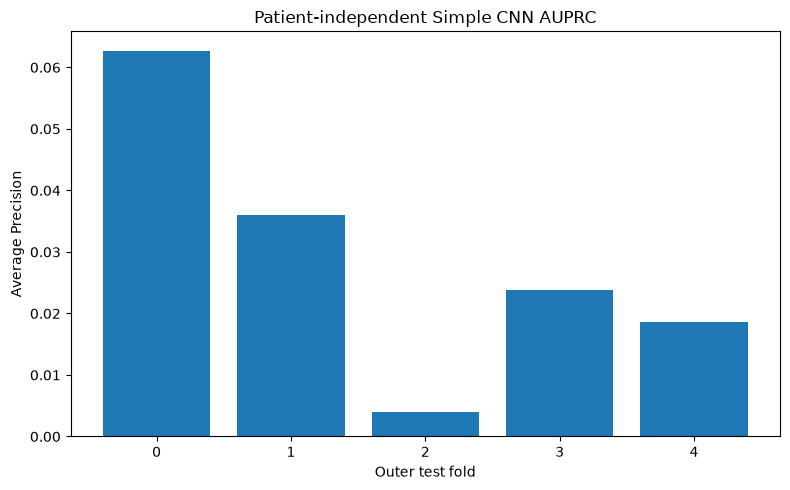

In [9]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    cnn_outer[
        "outer_fold"
    ].astype(str),
    cnn_outer[
        "average_precision"
    ],
)

ax.set_xlabel(
    "Outer test fold"
)

ax.set_ylabel(
    "Average Precision"
)

ax.set_title(
    "Patient-independent Simple CNN AUPRC"
)

fig.tight_layout()

fig.savefig(
    REPORT_DIR
    / "outer_auprc.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# AUROC Plot

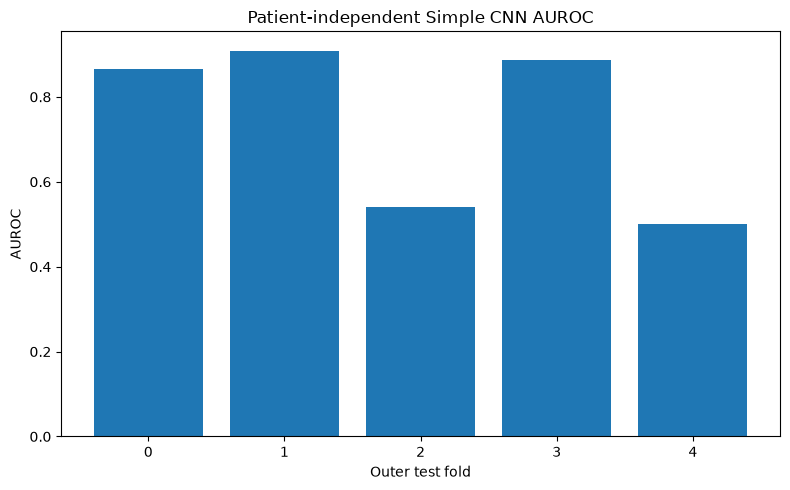

In [10]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    cnn_outer[
        "outer_fold"
    ].astype(str),
    cnn_outer[
        "roc_auc"
    ],
)

ax.set_xlabel(
    "Outer test fold"
)

ax.set_ylabel(
    "AUROC"
)

ax.set_title(
    "Patient-independent Simple CNN AUROC"
)

fig.tight_layout()

fig.savefig(
    REPORT_DIR
    / "outer_auroc.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Comparison of CNN and Constant Baseline

In [11]:
comparison = (
    outer_metrics.pivot(
        index="outer_fold",
        columns="model_name",
        values="average_precision",
    )
)

comparison

model_name,constant_prevalence,simple_cnn_v1
outer_fold,,
0,0.003868,0.062724
1,0.002817,0.036046
2,0.003835,0.003918
3,0.002678,0.023745
4,0.004946,0.018556


In [12]:
comparison[
    "improvement_over_constant"
] = (
    comparison[
        "simple_cnn_v1"
    ]
    - comparison[
        "constant_prevalence"
    ]
)

comparison

model_name,constant_prevalence,simple_cnn_v1,improvement_over_constant
outer_fold,,,
0,0.003868,0.062724,0.058856
1,0.002817,0.036046,0.033229
2,0.003835,0.003918,0.000083
3,0.002678,0.023745,0.021066
4,0.004946,0.018556,0.013609


# Patient-level AUPRC

In [13]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)


patient_rows = []

for subject_id, group in (
    predictions.groupby(
        "subject_id"
    )
):
    labels = (
        group[
            "true_label"
        ].astype(int)
    )

    if labels.nunique() < 2:
        patient_rows.append(
            {
                "subject_id": subject_id,
                "average_precision": np.nan,
                "roc_auc": np.nan,
                "positive_windows": int(
                    labels.sum()
                ),
                "negative_windows": int(
                    (labels == 0).sum()
                ),
            }
        )

        continue

    patient_rows.append(
        {
            "subject_id": subject_id,
            "average_precision": (
                average_precision_score(
                    labels,
                    group[
                        "probability"
                    ],
                )
            ),
            "roc_auc": (
                roc_auc_score(
                    labels,
                    group[
                        "probability"
                    ],
                )
            ),
            "positive_windows": int(
                labels.sum()
            ),
            "negative_windows": int(
                (labels == 0).sum()
            ),
        }
    )


patient_metrics = pd.DataFrame(
    patient_rows
)

patient_metrics.sort_values(
    "average_precision"
)

,subject_id,average_precision,roc_auc,positive_windows,negative_windows
12,subject_chb14,0.001153,0.157063,98,46676
1,subject_chb02,0.001892,0.581401,90,63353
4,subject_chb05,0.002229,0.143371,287,69879
8,subject_chb10,0.003943,0.634941,235,89781
3,subject_chb04,0.007919,0.923014,195,280677
7,subject_chb08,0.019028,0.486692,467,35524
17,subject_chb19,0.020779,0.921811,123,53720
10,subject_chb12,0.028793,0.668508,536,36680
5,subject_chb06,0.031517,0.720774,93,120011
6,subject_chb07,0.034030,0.943083,167,120507
